In [214]:
import os
import datetime
import json
import time
import matplotlib.pyplot as plt
import numpy as np

In [215]:
logfolder = 'O:/67203/OnWafMea/DR/Data/2025_05_01_Z_Positioners/Cooldown Logs/'
logs = os.listdir(logfolder)
datetimeobject = datetime.datetime.now()
yearstring = str(datetimeobject.year)[2:4]
monthstring = str(datetimeobject.month)
if len(monthstring) == 1:
    monthstring = '0' + monthstring
daystring = str(datetimeobject.day)
if len(daystring) == 1:
    daystring = '0' + daystring
datestring = yearstring + '-' + monthstring + '-' + daystring
logfiles = os.listdir(logfolder + datestring)
logfolder += datestring
logs = os.listdir(logfolder)
logs

['CH1 R 26-05-20.log',
 'CH1 T 26-05-20.log',
 'CH2 R 26-05-20.log',
 'CH2 T 26-05-20.log',
 'CH5 R 26-05-20.log',
 'CH5 T 26-05-20.log',
 'CH6 R 26-05-20.log',
 'CH6 T 26-05-20.log',
 'CH7 R 26-05-20.log',
 'CH7 T 26-05-20.log',
 'Channels 26-05-20.log',
 'Flowmeter 26-05-20.log',
 'Heaters 26-05-20.log',
 'maxigauge 26-05-20.log',
 'Status_26-05-20.log']

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

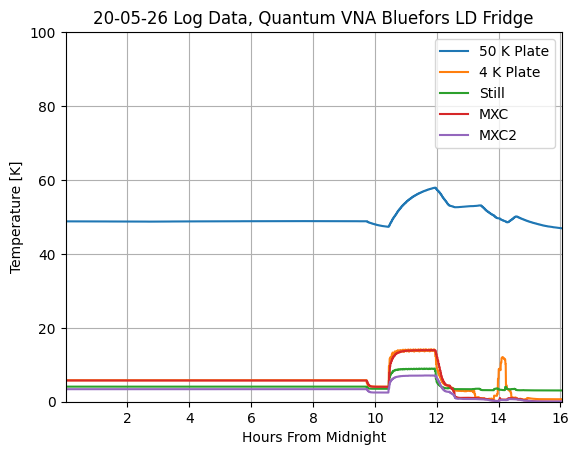

In [240]:
logdata = {}
for log in logs:
    if 'CH1 T' in log:
        f = open(logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['50kplate'] = {}
        logdata['50kplate']['date'] = datalist[0].split(',')[0]
        logdata['50kplate']['time'] = []
        logdata['50kplate']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['50kplate']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['50kplate']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH2 T' in log:
        f = open(logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['still'] = {}
        logdata['still']['date'] = datalist[0].split(',')[0]
        logdata['still']['time'] = []
        logdata['still']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['still']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['still']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH5 T' in log:
        f = open(logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['4kplate'] = {}
        logdata['4kplate']['date'] = datalist[0].split(',')[0]
        logdata['4kplate']['time'] = []
        logdata['4kplate']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['4kplate']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['4kplate']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH6 T' in log:
        f = open(logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['mxc'] = {}
        logdata['mxc']['date'] = datalist[0].split(',')[0]
        logdata['mxc']['time'] = []
        logdata['mxc']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['mxc']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['mxc']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH7 T' in log:
        f = open(logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['mxc2'] = {}
        logdata['mxc2']['date'] = datalist[0].split(',')[0]
        logdata['mxc2']['time'] = []
        logdata['mxc2']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['mxc2']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['mxc2']['temperature'].append(float(dataline.split(',')[2]))                

plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']))
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']))
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']))
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']))
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']))

plt.ylim([0,100])
plt.xlim([logdata['50kplate']['time'][0]/3600,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

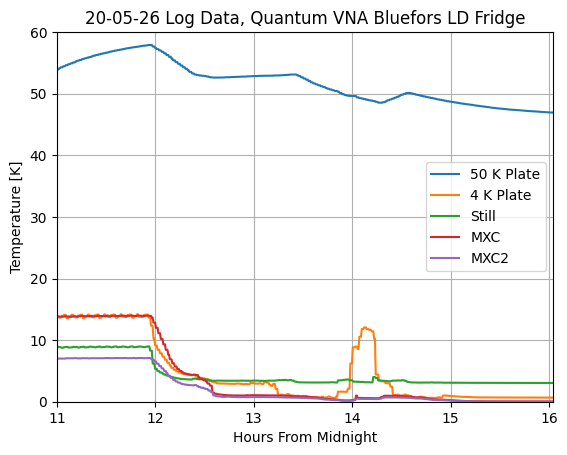

In [241]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']))
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']))
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']))
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']))
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']))

plt.ylim([0,60])
plt.xlim([11,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

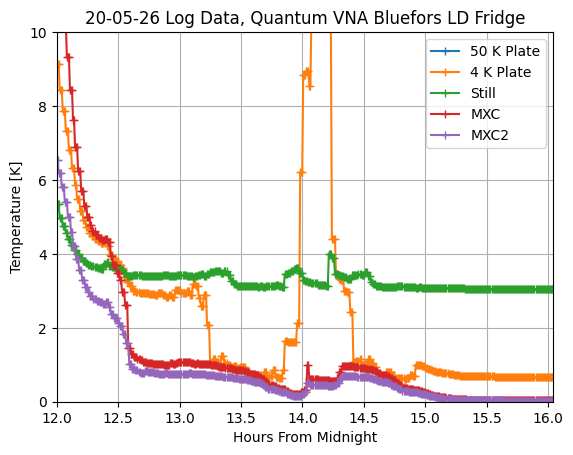

In [242]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']),'+-')
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']),'+-')
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']),'+-')
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']),'+-')
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']),'+-')

plt.ylim([0,10])
plt.xlim([12,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

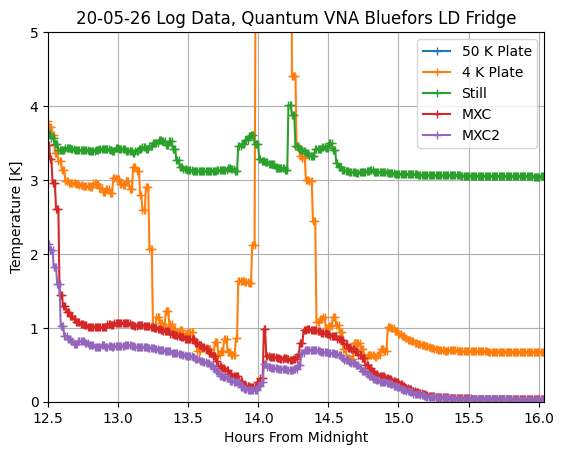

In [243]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']),'+-')
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']),'+-')
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']),'+-')
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']),'+-')
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']),'+-')

plt.ylim([0,5])
plt.xlim([12.5,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

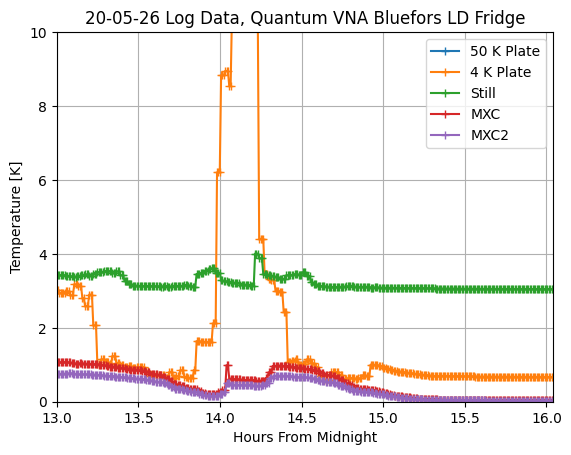

In [244]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']),'+-')
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']),'+-')
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']),'+-')
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']),'+-')
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']),'+-')

plt.ylim([0,10])
plt.xlim([13,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

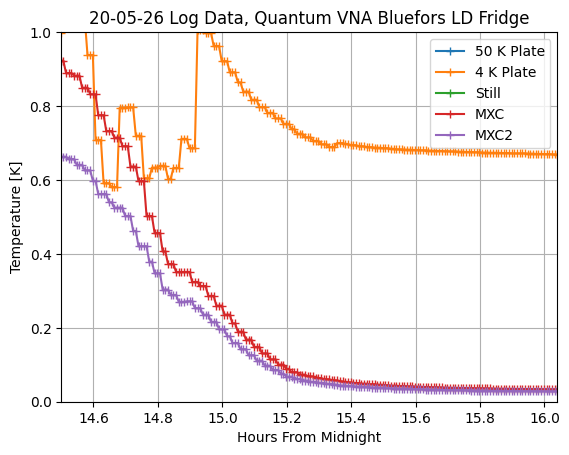

In [245]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']),'+-')
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']),'+-')
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']),'+-')
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']),'+-')
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']),'+-')

plt.ylim([0,1])
plt.xlim([14.5,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

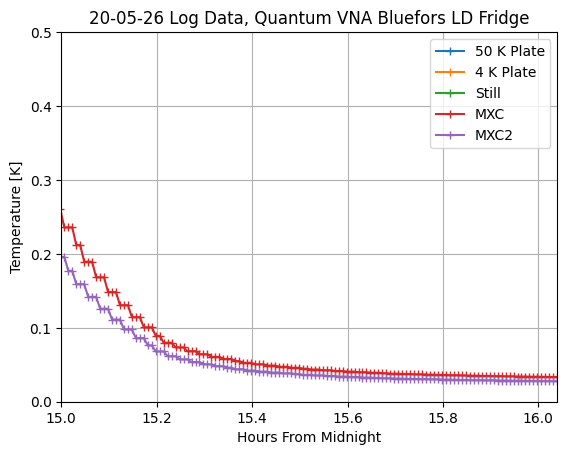

In [246]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']),'+-')
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']),'+-')
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']),'+-')
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']),'+-')
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']),'+-')

plt.ylim([0,0.5])
plt.xlim([15,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')

Text(0.5, 1.0, '20-05-26 Log Data, Quantum VNA Bluefors LD Fridge')

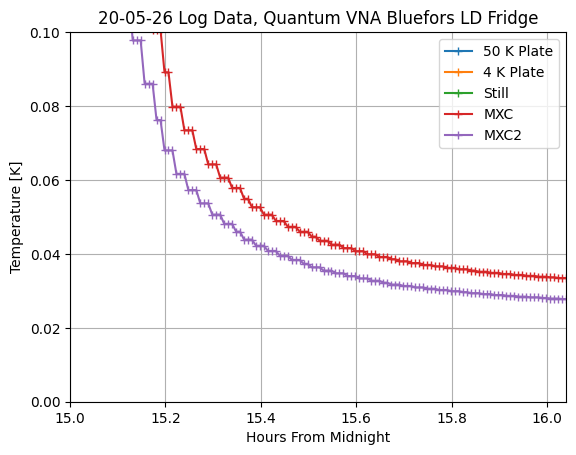

In [247]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']),'+-')
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']),'+-')
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']),'+-')
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']),'+-')
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']),'+-')

plt.ylim([0,0.1])
plt.xlim([15,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4 K Plate','Still','MXC','MXC2'])
plt.title(logdata['50kplate']['date'] + ' Log Data, Quantum VNA Bluefors LD Fridge')